## Metrica acc_at_least_one y acc_both vs interations

### Mnist - Crop

Usando mnist como dataset


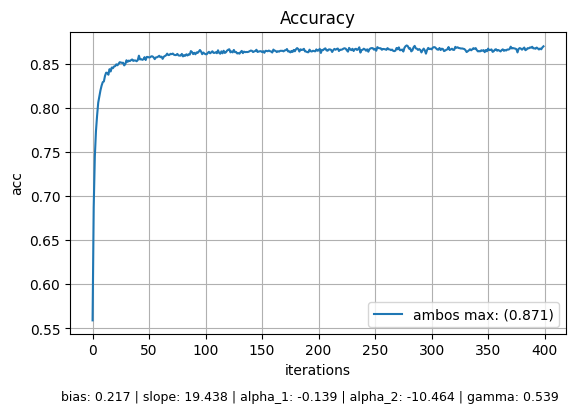

In [2]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from project.loader import load
from project.CROP.models.crop2 import Crop2

dataset = "mnist"
model="crop2"
#params="only_gamma"
lat=128
inter=256
cvae = load.cvae(lat=lat,inter=inter,dataset=dataset)
data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]


#mnist
mnist_params ={'bias': 0.21716868437244724, 'slope': 19.437646607877017, 'alpha_1': -0.13863158439804657, 'alpha_2': -10.463749682840565, 'gamma': 0.5392507616026618}

c = Crop2(cvae=cvae,predictor=predictor)

resuts=c.acc_curve(x_test[:],
    x_test_1[:],
     y_test[:],
     y_test_1[:],
     iterations=400,
     params=mnist_params,
     name=f"acc_vs_iterations_{dataset}_{model}_inter_{inter}_lat_{lat}_{mnist_params}")


## varios modelos


Usando fashion como dataset


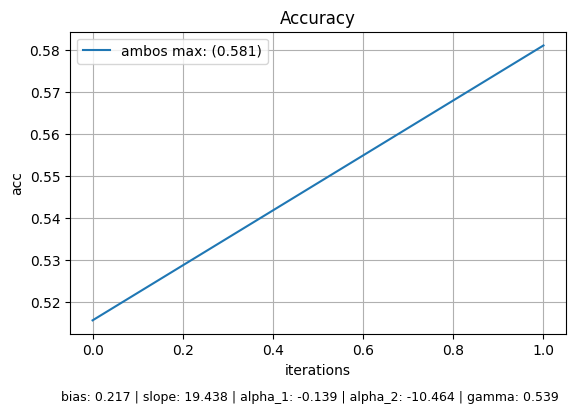

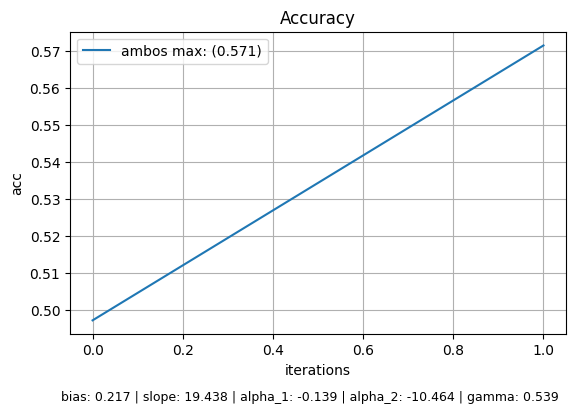

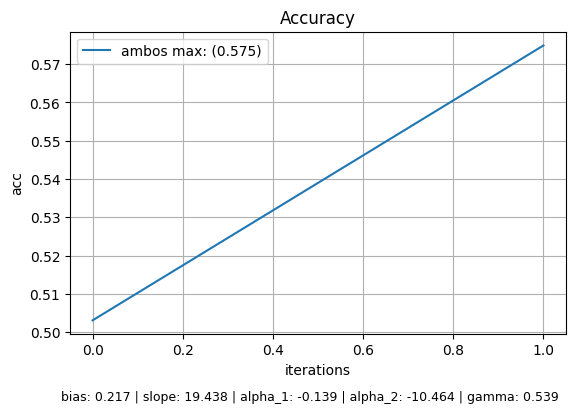

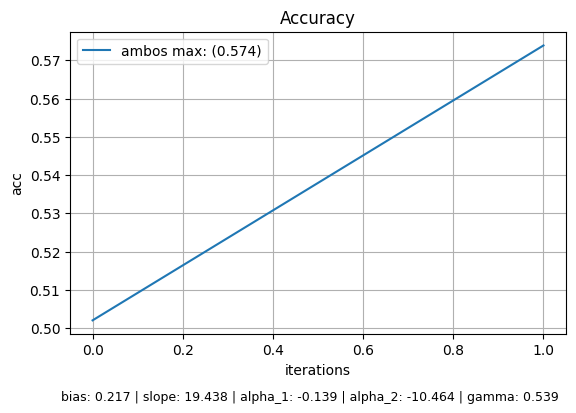

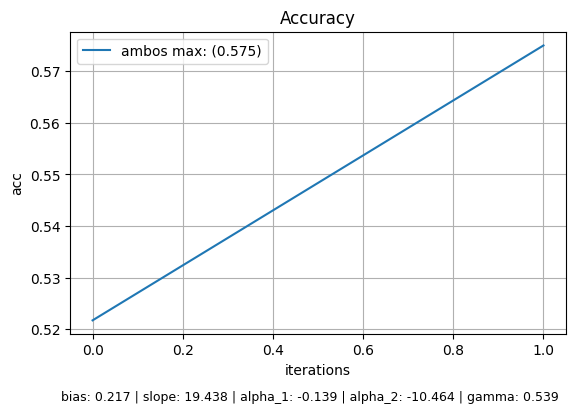

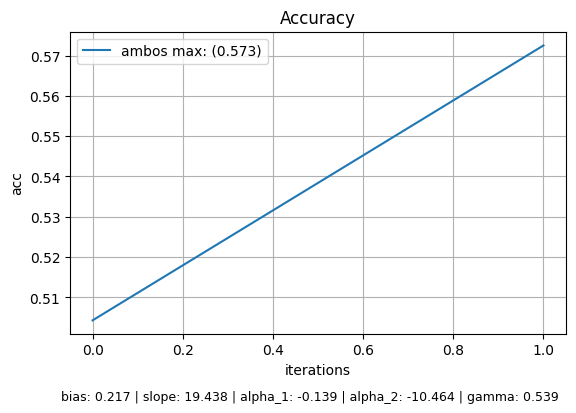

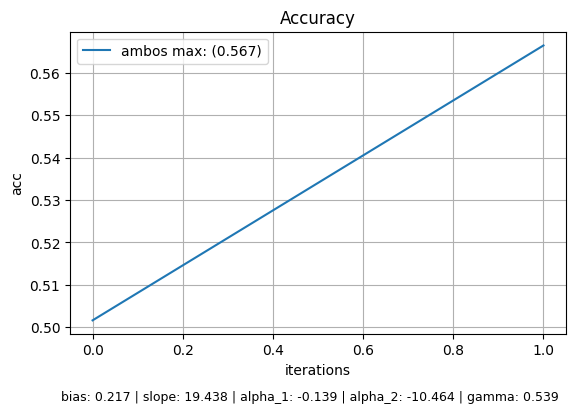

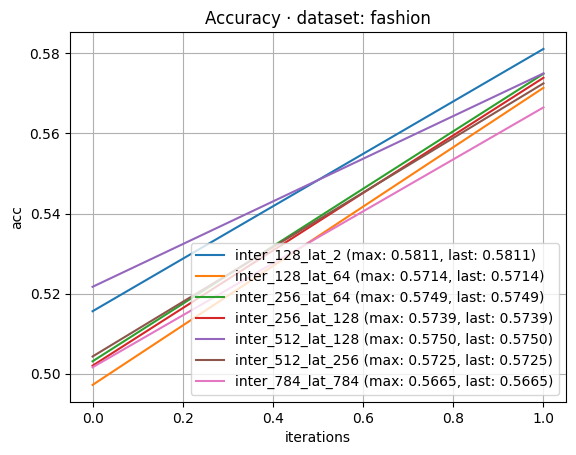

In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from project.loader import load
from project.CROP.models.crop2 import Crop2


# -------------------- config --------------------
DATASET = "fashion"
ITERATIONS = 2

MNIST_PARAMS = {
    'bias': 0.21716868437244724,
    'slope': 19.437646607877017,
    'alpha_1': -0.13863158439804657,
    'alpha_2': -10.463749682840565,
    'gamma': 0.5392507616026618
}

ARCHS = [
    (2,   128),
    (64,  128),
    (64,  256),
    (128, 256),
    (128, 512),
    (256, 512),
    (784, 784),
]


# -------------------- data & predictor --------------------
data = load.data(dataset=DATASET)
predictor = load.predictor(dataset=DATASET)

x_test, x_test_1 = data["x_test"], data["x_test_1"]
y_test, y_test_1 = data["y_test"], data["y_test_1"]


# -------------------- evaluation --------------------
results = {}

for lat, inter in ARCHS:
    cvae = load.cvae(lat=lat, inter=inter, dataset=DATASET)
    crop = Crop2(predictor=predictor, cvae=cvae)

    metrics = crop.acc_curve(
        x_test,
        x_test_1,
        y_test,
        y_test_1,
        iterations=ITERATIONS,
        params=MNIST_PARAMS
    )

    results[(lat, inter)] = metrics


# -------------------- plot --------------------
for (lat, inter), m in results.items():
    acc = m["acc_both_plot"]
    plt.plot(
        acc,
        label=f"inter_{inter}_lat_{lat} "
              f"(max: {np.max(acc):.4f}, last: {acc[-1]:.4f})"
    )

plt.grid()
plt.title(f"Accuracy · dataset: {DATASET}")
plt.xlabel("iterations")
plt.ylabel("acc")
plt.legend()
plt.savefig(f"acc_both_more_models_{DATASET}_________.png")
plt.show()


## Notas


comparacion de parametros con modelos 512 256

|Modelo/Dataset| mnist | Fashion | 
|:----------|:----------:|:------|
|CROP1|    0.8404      |    0.5955   |
|CROP2|     0.8478     | 0.6126      |
|CROP2_optim|   0.8602       | 0.6146      |
|CROP2_gamma| 0.842       | 0.6169      |


## compración de distintos modelos
todos crop 2



|Modelo/Dataset| mnist | Fashion | 
|:----------|:----------:|:------|
|2 128|    0.7499      |    0.5998   |
|64 128|     0.8516     | 0.6151     |
|128 256|   0.8643       | 0.6153      | 
|256 512| 0.8467       | 0.6129     |
|2 128 opt|    0.7659      |    0.6138   |
|64 128 opt|     0.8618     | 0.6267      |
|128 256 opt|   0.875       | 0.6257      |
|256 512 opt| 0.8601       | 0.6158      |


---------------------------------------------------------------------------------------------------------------------------------------------


PSNR

_________________________________________________

Usando mnist como dataset


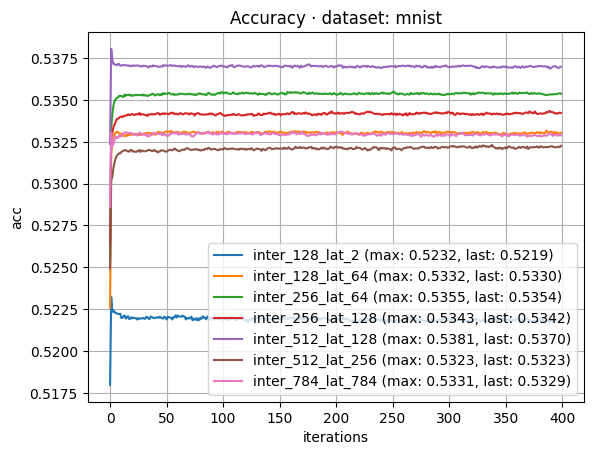

In [4]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from project.loader import load
from project.CROP.models.crop2 import Crop2


# -------------------- config --------------------
DATASET = "mnist"
ITERATIONS = 400
MET="ssim"
MNIST_PARAMS = {
    'bias': 0.21716868437244724,
    'slope': 19.437646607877017,
    'alpha_1': -0.13863158439804657,
    'alpha_2': -10.463749682840565,
    'gamma': 0.5392507616026618
}

ARCHS = [
    (2,   128),
    (64,  128),
    (64,  256),
    (128, 256),
    (128, 512),
    (256, 512),
    (784, 784),
]


# -------------------- data & predictor --------------------
data = load.data(dataset=DATASET)
predictor = load.predictor(dataset=DATASET)

x_test, x_test_1 = data["x_test"], data["x_test_1"]
y_test, y_test_1 = data["y_test"], data["y_test_1"]


# -------------------- evaluation --------------------
results = {}

for lat, inter in ARCHS:
    cvae = load.cvae(lat=lat, inter=inter, dataset=DATASET)
    crop = Crop2(predictor=predictor, cvae=cvae)

    metrics = crop.ssim_curve(
        x_test,
        x_test_1,
        y_test,
        y_test_1,
        iterations=ITERATIONS,
        #params=MNIST_PARAMS
    )

    results[(lat, inter)] = metrics


# -------------------- plot --------------------
for (lat, inter), m in results.items():
    met = m["ssim_mean"]
    plt.plot(
        met,
        label=f"inter_{inter}_lat_{lat} "
              f"(max: {np.max(met):.4f}, last: {met[-1]:.4f})"
    )

plt.grid()
plt.title(f"Accuracy · dataset: {DATASET}")
plt.xlabel("iterations")
plt.ylabel("acc")
plt.legend()
plt.savefig(f"acc_both_more_models_{DATASET}_{MET}.png")
plt.show()
